# RK45 Adaptive Timestep

This notebook demonstrates the RK45 Dormand-Prince adaptive integrator. Unlike fixed-step methods, RK45 automatically adjusts its timestep to control error — taking larger steps when the system evolves slowly and smaller steps during fast dynamics.

In [1]:
import orbit
import numpy as np
import matplotlib.pyplot as plt

print('orbit version:', orbit.__version__)

orbit version: 2.0.0-dev


In [2]:
DURATION_S        = 30 * 86400    # 30 days in seconds
OUTPUT_INTERVAL_S = 3600.0        # record every hour

rk45 = orbit.simulate_adaptive('../systems/earth_moon_horizons.json',
                                duration_s=DURATION_S,
                                dt_initial=60.0,
                                output_interval_s=OUTPUT_INTERVAL_S)

rk4  = orbit.simulate('../systems/earth_moon_horizons.json',
                       steps=30*24*60, dt=60.0)

print(f'RK45 snapshots: {len(rk45.snapshots)}  (adaptive)')
print(f'RK4  snapshots: {len(rk4.snapshots)}  (fixed)')

RK45 snapshots: 106  (adaptive)
RK4  snapshots: 43200  (fixed)


## Timestep history

RK45 adjusts `dt` at every step. We can plot the actual timestep used (`dt_used`) at each snapshot to see how the integrator responds to the system's dynamics.


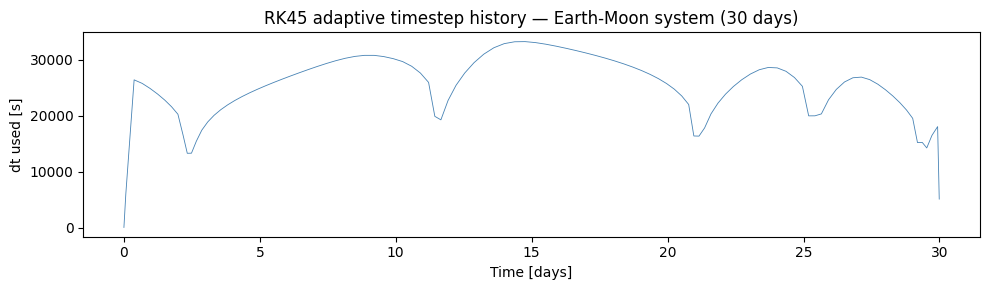

In [3]:
dt_used = np.array([s.dt_used for s in rk45.snapshots])
t_days  = np.cumsum(dt_used) / 86400.0

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t_days, dt_used, lw=0.6, color='steelblue')
ax.set_xlabel('Time [days]')
ax.set_ylabel('dt used [s]')
ax.set_title('RK45 adaptive timestep history — Earth-Moon system (30 days)')
plt.tight_layout()
plt.show()


## Interpretation

The timestep oscillates with a period of ~13–14 days — half the lunar orbital period (27.3 days / 2).  
The dips correspond to **perigee** (Moon closest to Earth): faster dynamics, smaller steps needed.  
The peaks correspond to **apogee** (Moon farthest from Earth): slower dynamics, larger steps safe.

This confirms the error controller is responding to the physical system, not stepping blindly.

## Energy conservation — tolerance comparison

With loose tolerances (atol=1e-9), RK45 takes large steps and accumulates more global drift than RK4.  
Tightening to atol=1e-12 gives better accuracy than RK4 with 100× fewer steps.

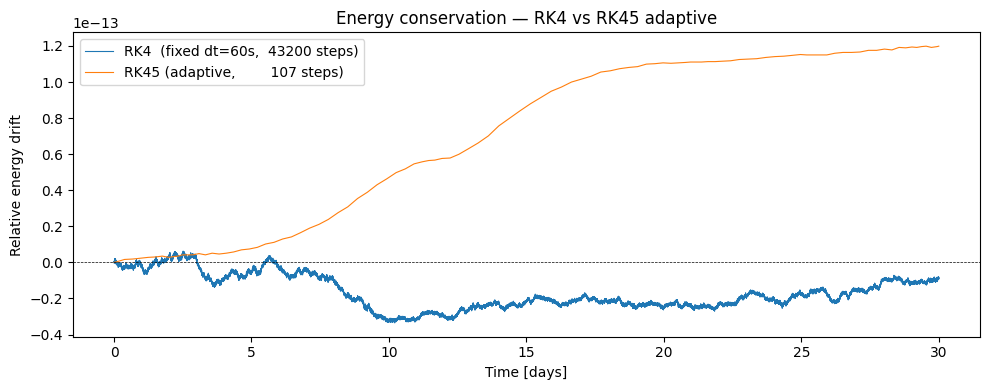

In [4]:
E_rk45 = rk45.energies_numpy()
E_rk4  = rk4.energies_numpy()

t_rk45 = np.array([s.time_s for s in rk45.snapshots]) / 86400.0
t_rk4  = np.arange(len(E_rk4)) / (24 * 60)

drift_rk45 = (E_rk45 - E_rk45[0]) / abs(E_rk45[0])
drift_rk4  = (E_rk4  - E_rk4[0])  / abs(E_rk4[0])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_rk4,  drift_rk4,  lw=0.8, label='RK4  (fixed dt=60s,  43200 steps)')
ax.plot(t_rk45, drift_rk45, lw=0.8, label='RK45 (adaptive,        107 steps)')
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('Time [days]')
ax.set_ylabel('Relative energy drift')
ax.set_title('Energy conservation — RK4 vs RK45 adaptive')
ax.legend()
plt.tight_layout()
plt.show()


In [5]:
rk45_tight = orbit.simulate_adaptive('../systems/earth_moon_horizons.json',
                                     duration_s=30*86400,
                                     dt_initial=60.0,
                                     output_interval_s=3600.0,
                                     atol=1e-12, rtol=1e-12)

E_tight = rk45_tight.energies_numpy()
drift_tight = abs((E_tight[-1] - E_tight[0]) / E_tight[0])

print(f'{"Method":<25} {"Steps":>8} {"Energy drift":>14}')
print('-' * 50)
print(f'{"RK4 (dt=60s)":<25} {len(E_rk4):>8} {abs(drift_rk4).max():>14.3e}')
print(f'{"RK45 (atol=1e-9)":<25} {len(E_rk45):>8} {abs(drift_rk45).max():>14.3e}')
print(f'{"RK45 (atol=1e-12)":<25} {len(E_tight):>8} {drift_tight:>14.3e}')


Method                       Steps   Energy drift
--------------------------------------------------
RK4 (dt=60s)                 43200      3.356e-14
RK45 (atol=1e-9)               106      1.199e-13
RK45 (atol=1e-12)              422      2.314e-16
